# 6.6 - CertCF Adult atlas visualization

This notebook builds the Adult CertCF atlas with class-wise `k`-medoids and `k_per_class = 200`, then visualizes the training support, selected anchors, and sampled points from the original certified polytopes in 2D.

Two embeddings are provided:
- `PCA`: primary view, because it preserves a fixed linear map from the original feature space.
- `t-SNE`: optional secondary view for local neighborhood structure.

Important note:
The sampled polytope points are drawn from the original continuous certified polytopes before any OHE decoding. For Adult, that means these samples visualize the continuous certified regions used by the atlas, not only exact valid one-hot counterfactual outputs.

In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from scipy.spatial import ConvexHull, QhullError
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torch.utils.data import TensorDataset

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from certcf import CertCFAtlas, NearestOppositeClassClearanceStrategy
from counterfactuals.benchmarks import create_default_registries
from counterfactuals.utils.clustering import select_prototype_indices
from scripts.benchmark import _build_torch_model_from_checkpoint

sns.set_theme(style='whitegrid', context='talk')
np.set_printoptions(precision=4, suppress=True)

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [2]:
CONFIG_PATH = ROOT / 'configs/benchmarks/benchmark_meeting_all_200q.yaml'
DATASET_NAME = 'adult'
K_PER_CLASS = 200
SUBSAMPLE_METHOD = 'kmedoids'
LIRPA_METHOD = 'backward'
EPS_ALPHA = 0.45
SEED = 42

VIS_POINTS_PER_CLASS = 1500
TSNE_POINTS_PER_CLASS = 1000
POLYTOPES_PER_CLASS = 12
SAMPLES_PER_POLYTOPE = 40
POLYTOPE_PROPOSAL_BATCH = 2048
POLYTOPE_MAX_BATCHES = 40
TSNE_ENABLED = True
TSNE_PERPLEXITY = 35
TSNE_PCA_PRECOMPONENTS = 20

print(CONFIG_PATH)
print({
    'dataset': DATASET_NAME,
    'k_per_class': K_PER_CLASS,
    'subsample_method': SUBSAMPLE_METHOD,
    'lirpa_method': LIRPA_METHOD,
    'eps_alpha': EPS_ALPHA,
    'tsne_enabled': TSNE_ENABLED,
})

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/configs/benchmarks/benchmark_meeting_all_200q.yaml
{'dataset': 'adult', 'k_per_class': 200, 'subsample_method': 'kmedoids', 'lirpa_method': 'backward', 'eps_alpha': 0.45, 'tsne_enabled': True}


In [3]:
with CONFIG_PATH.open() as f:
    BENCHMARK_CFG = yaml.safe_load(f)

DATASET_CFGS = {cfg['name']: cfg for cfg in BENCHMARK_CFG['datasets']}
SHARED_METHOD_CFGS = {cfg['name']: cfg for cfg in BENCHMARK_CFG['methods']}
REGISTRIES = create_default_registries()


def _resolve_repo_path(path_value):
    path = Path(path_value)
    if path.is_absolute():
        return path
    candidates = [ROOT / path, Path.cwd() / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return (ROOT / path).resolve()


def _resolve_norm(raw_value):
    text = str(raw_value).strip().lower()
    if text in {'inf', 'infinity'}:
        return np.inf
    return int(raw_value)


def _batched_logits(model_wrapper, x, batch_size=2048):
    module = model_wrapper.model.eval()
    device = torch.device(model_wrapper.device)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            x_batch = torch.from_numpy(np.asarray(x[start:start + batch_size], dtype=np.float32)).to(device)
            logits = module(x_batch).detach().cpu().numpy()
            outputs.append(logits)
    return np.concatenate(outputs, axis=0)


def _batched_penultimate_embeddings(model_wrapper, x, batch_size=2048):
    module = model_wrapper.model.eval()
    if not hasattr(module, '__getitem__') or len(module) < 2:
        raise ValueError('Expected a sequential classifier with a final linear layer.')
    feature_extractor = module[:-1]
    final_linear = module[-1]
    if not isinstance(final_linear, torch.nn.Linear):
        raise ValueError('Expected the last classifier layer to be Linear.')

    device = torch.device(model_wrapper.device)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            x_batch = torch.from_numpy(np.asarray(x[start:start + batch_size], dtype=np.float32)).to(device)
            z_batch = feature_extractor(x_batch).detach().cpu().numpy()
            outputs.append(z_batch)
    return np.concatenate(outputs, axis=0)


def _margin_scores(logits, y_true):
    logits = np.asarray(logits, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.int64)
    true_scores = logits[np.arange(len(y_true)), y_true]
    masked = logits.copy()
    masked[np.arange(len(y_true)), y_true] = -np.inf
    other_scores = masked.max(axis=1)
    return true_scores - other_scores


def _load_adult_bundle(dataset_name=DATASET_NAME):
    ds_cfg = DATASET_CFGS[dataset_name]
    dataset_params = dict(ds_cfg.get('dataset_params', {'data_dir': 'data/'}))
    dataset_params['data_dir'] = str(_resolve_repo_path(dataset_params.get('data_dir', 'data/')))
    dataset = REGISTRIES['dataset'].create(dataset_name, **dataset_params)
    dataset.load()

    x_train, y_train = dataset.get_train()
    x_test, y_test = dataset.get_test()

    model_cfg = ds_cfg['model']
    model_params = dict(model_cfg.get('params', {}))
    model_params['checkpoint'] = str(_resolve_repo_path(model_params['checkpoint']))
    model = _build_torch_model_from_checkpoint(
        checkpoint=model_params['checkpoint'],
        device=model_params.get('device', 'cpu'),
        dataset_module=model_params.get('dataset_module', dataset_name),
        hidden_dims=list(model_params.get('hidden_dims', [32, 8])),
        dropout=float(model_params.get('dropout', 0.2)),
    )

    certcf_params = dict(SHARED_METHOD_CFGS['certcf'].get('params', {}))
    certcf_params.update(ds_cfg.get('method_overrides', {}).get('certcf', {}))
    cert_norm = _resolve_norm(certcf_params.get('norm', 2))
    distance_norm = _resolve_norm(certcf_params.get('distance_norm', cert_norm))
    query_method = str(certcf_params.get('query_method', 'sorted')).lower()

    spec = getattr(dataset, 'spec', None)
    ohe_slices = list(spec.categorical_slices) if spec is not None and len(spec.categorical_slices) else None

    logits = _batched_logits(model, x_train)
    margins = _margin_scores(logits, y_train)

    return {
        'dataset_name': dataset_name,
        'dataset': dataset,
        'spec': spec,
        'x_train': np.asarray(x_train, dtype=np.float32),
        'y_train': np.asarray(y_train, dtype=np.int64),
        'x_test': np.asarray(x_test, dtype=np.float32),
        'y_test': np.asarray(y_test, dtype=np.int64),
        'model': model,
        'model_cfg': model_cfg,
        'certcf_params': certcf_params,
        'cert_norm': cert_norm,
        'distance_norm': distance_norm,
        'query_method': query_method,
        'ohe_slices': ohe_slices,
        'margin_scores': margins,
        'class_labels': [int(v) for v in np.unique(y_train)],
    }


def _select_prototypes_per_class(x_train, y_train, class_labels, k_per_class, method, margin_scores):
    selected = []
    per_class = []
    for class_label in class_labels:
        cls_idx = np.where(y_train == class_label)[0]
        k_cls = min(int(k_per_class), len(cls_idx))
        local_idx = np.asarray(
            select_prototype_indices(x_train[cls_idx], k=k_cls, method=method, random_state=SEED),
            dtype=np.int64,
        )
        absolute_idx = cls_idx[local_idx]
        selected.append(absolute_idx)
        per_class.append({
            'class_label': int(class_label),
            'n_available': int(len(cls_idx)),
            'n_selected': int(len(absolute_idx)),
            'selected_margin_mean': float(np.mean(margin_scores[absolute_idx])),
            'selected_margin_median': float(np.median(margin_scores[absolute_idx])),
        })
    return np.concatenate(selected).astype(np.int64), pd.DataFrame(per_class)


def _build_atlas(bundle, selected_idx):
    x_proto = bundle['x_train'][selected_idx]
    y_proto = bundle['y_train'][selected_idx]
    params = bundle['certcf_params']
    atlas = CertCFAtlas(
        model=bundle['model'].model,
        dataset=TensorDataset(torch.from_numpy(x_proto).float(), torch.from_numpy(y_proto).long()),
        device=bundle['model'].device,
        cnn=False,
        norm=bundle['cert_norm'],
        distance_norm=bundle['distance_norm'],
        eps_strategy=NearestOppositeClassClearanceStrategy(alpha=EPS_ALPHA),
        batch_size=int(params.get('batch_size', 256)),
        ohe_slices=bundle['ohe_slices'],
        default_query_method=bundle['query_method'],
        solver_maxiter=int(params.get('solver_maxiter', 500)),
        lirpa_method=LIRPA_METHOD,
    )
    t0 = time.perf_counter()
    atlas.build(verbose=False)
    build_time_s = time.perf_counter() - t0
    return atlas, build_time_s


def _sample_indices_per_class(y, class_labels, n_per_class, seed_offset=0):
    rng = np.random.default_rng(SEED + seed_offset)
    selected = []
    for class_label in class_labels:
        cls_idx = np.where(y == int(class_label))[0]
        n_pick = min(int(n_per_class), len(cls_idx))
        picked = np.sort(rng.choice(cls_idx, size=n_pick, replace=False)) if n_pick < len(cls_idx) else cls_idx
        selected.append(picked.astype(np.int64))
    return np.concatenate(selected).astype(np.int64)


def _sample_uniform_ball(center, radius, n_samples, norm, rng):
    center = np.asarray(center, dtype=np.float64)
    d = center.shape[0]
    if radius <= 0 or n_samples <= 0:
        return np.repeat(center[None, :], repeats=max(n_samples, 0), axis=0)

    if norm == 1:
        weights = rng.exponential(scale=1.0, size=(n_samples, d))
        weights /= weights.sum(axis=1, keepdims=True)
        signs = rng.choice(np.array([-1.0, 1.0]), size=(n_samples, d))
        shell = weights * signs
        radii = rng.random(n_samples) ** (1.0 / d)
        return center + radius * radii[:, None] * shell

    if norm == 2:
        directions = rng.normal(size=(n_samples, d))
        norms = np.linalg.norm(directions, axis=1, keepdims=True)
        norms = np.maximum(norms, 1e-12)
        directions /= norms
        radii = rng.random(n_samples) ** (1.0 / d)
        return center + radius * radii[:, None] * directions

    if norm == np.inf:
        return center + rng.uniform(-radius, radius, size=(n_samples, d))

    raise ValueError(f'Unsupported norm for ball sampling: {norm!r}')


def _sample_polytope_points(atlas, class_label, anchor_idx, n_keep, proposal_batch_size, max_batches, rng):
    bd = atlas.bounds[int(class_label)]
    center = np.asarray(bd['X'][anchor_idx], dtype=np.float64)
    A_full, b_full, _, ball_eps = atlas._erode_constraints(
        bd['lA'][anchor_idx],
        bd['lbias'][anchor_idx],
        center,
        len(center),
        0.0,
        atlas.norm,
        float(bd['eps'][anchor_idx]),
    )
    if A_full is None:
        return np.empty((0, len(center)), dtype=np.float64), {
            'class_label': int(class_label),
            'anchor_idx': int(anchor_idx),
            'n_requested': int(n_keep),
            'n_accepted': 0,
            'n_drawn': 0,
            'acceptance_rate': 0.0,
            'ball_eps': float(bd['eps'][anchor_idx]),
        }

    accepted_batches = []
    accepted = 0
    drawn = 0
    for _ in range(int(max_batches)):
        proposals = _sample_uniform_ball(center, float(ball_eps), int(proposal_batch_size), atlas.norm, rng)
        mask = np.all((A_full @ proposals.T) + b_full[:, None] >= -1e-8, axis=0)
        chosen = proposals[mask]
        if len(chosen):
            accepted_batches.append(chosen)
            accepted += len(chosen)
        drawn += len(proposals)
        if accepted >= n_keep:
            break

    if accepted_batches:
        samples = np.concatenate(accepted_batches, axis=0)[:n_keep]
    else:
        samples = np.empty((0, len(center)), dtype=np.float64)

    return samples, {
        'class_label': int(class_label),
        'anchor_idx': int(anchor_idx),
        'n_requested': int(n_keep),
        'n_accepted': int(len(samples)),
        'n_drawn': int(drawn),
        'acceptance_rate': float(len(samples) / drawn) if drawn else 0.0,
        'ball_eps': float(bd['eps'][anchor_idx]),
    }


def _sample_polytope_clouds(atlas, selected_idx, y_selected, n_polytopes_per_class=POLYTOPES_PER_CLASS, n_samples_per_polytope=SAMPLES_PER_POLYTOPE):
    rng = np.random.default_rng(SEED + 2026)
    cloud_rows = []
    sample_meta = []

    for class_label in atlas.class_labels:
        class_global_positions = np.where(y_selected == int(class_label))[0]
        if len(class_global_positions) == 0:
            continue
        class_local_indices = np.arange(len(class_global_positions), dtype=np.int64)
        n_pick = min(int(n_polytopes_per_class), len(class_local_indices))
        picked_local_indices = (
            np.sort(rng.choice(class_local_indices, size=n_pick, replace=False))
            if n_pick < len(class_local_indices)
            else class_local_indices
        )
        for local_idx in picked_local_indices:
            anchor_idx = int(local_idx)
            global_pos = int(class_global_positions[local_idx])
            samples, stats = _sample_polytope_points(
                atlas,
                class_label=int(class_label),
                anchor_idx=anchor_idx,
                n_keep=int(n_samples_per_polytope),
                proposal_batch_size=int(POLYTOPE_PROPOSAL_BATCH),
                max_batches=int(POLYTOPE_MAX_BATCHES),
                rng=rng,
            )
            stats['selected_train_idx'] = int(selected_idx[global_pos])
            sample_meta.append(stats)
            if len(samples) == 0:
                continue
            df = pd.DataFrame(samples)
            df['class_label'] = int(class_label)
            df['anchor_idx'] = int(anchor_idx)
            df['selected_train_idx'] = int(selected_idx[global_pos])
            cloud_rows.append(df)

    if cloud_rows:
        cloud_df = pd.concat(cloud_rows, ignore_index=True)
    else:
        cloud_df = pd.DataFrame(columns=list(range(atlas.bounds[atlas.class_labels[0]]['X'].shape[1])) + ['class_label', 'anchor_idx', 'selected_train_idx'])
    return cloud_df, pd.DataFrame(sample_meta)


def _fit_pca(train_points, n_components=2):
    pca = PCA(n_components=n_components, random_state=SEED)
    pca.fit(train_points)
    return pca




def _plot_embedding_points(df_embed, title, ax, *, label_col='class_label', legend_prefix='Class', zoom_quantiles=None):
    palette = {0: '#3182bd', 1: '#e6550d'}
    for class_label in sorted(df_embed[label_col].unique()):
        subset = df_embed[df_embed[label_col] == class_label]
        ax.scatter(
            subset['dim_1'], subset['dim_2'],
            s=14, alpha=0.28,
            c=palette.get(int(class_label), '#666666'),
            label=f'{legend_prefix} {class_label}',
        )
    if zoom_quantiles is not None and len(df_embed):
        q_low, q_high = zoom_quantiles
        x_low, x_high = np.quantile(df_embed['dim_1'], [q_low, q_high])
        y_low, y_high = np.quantile(df_embed['dim_2'], [q_low, q_high])
        x_pad = max(0.01, 0.1 * (x_high - x_low))
        y_pad = max(0.01, 0.1 * (y_high - y_low))
        ax.set_xlim(x_low - x_pad, x_high + x_pad)
        ax.set_ylim(y_low - y_pad, y_high + y_pad)
    ax.set_title(title)
    ax.set_xlabel('dim 1')
    ax.set_ylabel('dim 2')
    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    ax.legend(dedup.values(), dedup.keys(), loc='best', frameon=True, fontsize=10)

def _fit_tsne(all_points):
    pre_dim = min(int(TSNE_PCA_PRECOMPONENTS), all_points.shape[1], max(2, all_points.shape[0] - 1))
    if pre_dim >= 2 and pre_dim < all_points.shape[1]:
        pca_pre = PCA(n_components=pre_dim, random_state=SEED)
        reduced = pca_pre.fit_transform(all_points)
    else:
        reduced = all_points
    tsne = TSNE(
        n_components=2,
        random_state=SEED,
        init='pca',
        learning_rate='auto',
        perplexity=min(TSNE_PERPLEXITY, max(5, (len(reduced) - 1) // 3)),
    )
    return tsne.fit_transform(reduced)


def _make_embedding_frames(bundle, selected_idx, cloud_df):
    base_idx = _sample_indices_per_class(bundle['y_train'], bundle['class_labels'], VIS_POINTS_PER_CLASS, seed_offset=111)
    base_df = pd.DataFrame(bundle['x_train'][base_idx])
    base_df['kind'] = 'train_support'
    base_df['class_label'] = bundle['y_train'][base_idx]
    base_df['selected_train_idx'] = base_idx
    base_df['anchor_idx'] = -1

    anchor_df = pd.DataFrame(bundle['x_train'][selected_idx])
    anchor_df['kind'] = 'anchor'
    anchor_df['class_label'] = bundle['y_train'][selected_idx]
    anchor_df['selected_train_idx'] = selected_idx
    anchor_df['anchor_idx'] = np.arange(len(selected_idx), dtype=np.int64)

    poly_df = cloud_df.copy()
    feature_cols = list(range(bundle['x_train'].shape[1]))
    poly_df['kind'] = 'polytope_sample'

    combined = pd.concat([
        base_df[feature_cols + ['kind', 'class_label', 'selected_train_idx', 'anchor_idx']],
        anchor_df[feature_cols + ['kind', 'class_label', 'selected_train_idx', 'anchor_idx']],
        poly_df[feature_cols + ['kind', 'class_label', 'selected_train_idx', 'anchor_idx']],
    ], ignore_index=True)
    return combined


def _plot_pca_polytopes(df_embed, title, ax, *, show_support=True, zoom_to_polytopes=False):
    palette_support = {0: '#9ecae1', 1: '#fdd0a2'}
    palette_poly = {0: '#08519c', 1: '#a63603'}

    support = df_embed[df_embed['kind'] == 'train_support']
    samples = df_embed[df_embed['kind'] == 'polytope_sample']

    if show_support:
        for class_label in sorted(df_embed['class_label'].unique()):
            subset = support[support['class_label'] == class_label]
            ax.scatter(
                subset['dim_1'], subset['dim_2'],
                s=12, alpha=0.12,
                c=palette_support.get(class_label, '#cccccc'),
                label=f'Train class {class_label}',
            )

    polygon_labels_used = set()
    point_labels_used = set()
    for (class_label, anchor_idx), subset in samples.groupby(['class_label', 'anchor_idx']):
        color = palette_poly.get(int(class_label), '#444444')
        points = subset[['dim_1', 'dim_2']].to_numpy(dtype=np.float64)
        if len(points) >= 3:
            try:
                hull = ConvexHull(points)
                polygon = Polygon(
                    points[hull.vertices],
                    closed=True,
                    facecolor=color,
                    edgecolor=color,
                    alpha=0.28,
                    linewidth=2.0,
                    label=None if class_label in polygon_labels_used else f'Projected polytope class {class_label}',
                )
                ax.add_patch(polygon)
                polygon_labels_used.add(class_label)
            except QhullError:
                pass
        ax.scatter(
            subset['dim_1'], subset['dim_2'],
            s=10, alpha=0.18 if show_support else 0.28,
            c=color,
            linewidths=0.0,
            label=None if class_label in point_labels_used else f'Polytope samples class {class_label}',
        )
        point_labels_used.add(class_label)

    if zoom_to_polytopes and len(samples):
        x_min = float(samples['dim_1'].min())
        x_max = float(samples['dim_1'].max())
        y_min = float(samples['dim_2'].min())
        y_max = float(samples['dim_2'].max())
        x_pad = max(0.01, 0.15 * (x_max - x_min))
        y_pad = max(0.01, 0.15 * (y_max - y_min))
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

    ax.set_title(title)
    ax.set_xlabel('dim 1')
    ax.set_ylabel('dim 2')

    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    ax.legend(dedup.values(), dedup.keys(), loc='best', frameon=True, fontsize=10)


def _plot_tsne_embedding(df_embed, title, ax):
    palette_support = {0: '#9ecae1', 1: '#fdd0a2'}
    palette_poly = {0: '#08519c', 1: '#a63603'}

    support = df_embed[df_embed['kind'] == 'train_support']
    samples = df_embed[df_embed['kind'] == 'polytope_sample']

    for class_label in sorted(df_embed['class_label'].unique()):
        subset = support[support['class_label'] == class_label]
        ax.scatter(
            subset['dim_1'], subset['dim_2'],
            s=14, alpha=0.22,
            c=palette_support.get(class_label, '#cccccc'),
            label=f'Train class {class_label}',
        )

    for class_label in sorted(df_embed['class_label'].unique()):
        subset = samples[samples['class_label'] == class_label]
        if len(subset):
            ax.scatter(
                subset['dim_1'], subset['dim_2'],
                s=12, alpha=0.45,
                c=palette_poly.get(class_label, '#444444'),
                label=f'Polytope samples class {class_label}',
            )

    ax.set_title(title)
    ax.set_xlabel('dim 1')
    ax.set_ylabel('dim 2')

    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    ax.legend(dedup.values(), dedup.keys(), loc='best', frameon=True, fontsize=10)


In [4]:
bundle = _load_adult_bundle()
selected_idx, selection_summary = _select_prototypes_per_class(
    bundle['x_train'],
    bundle['y_train'],
    bundle['class_labels'],
    k_per_class=K_PER_CLASS,
    method=SUBSAMPLE_METHOD,
    margin_scores=bundle['margin_scores'],
)
atlas, atlas_build_time_s = _build_atlas(bundle, selected_idx)

atlas_overview = pd.DataFrame([
    {
        'dataset': bundle['dataset_name'],
        'n_train': int(len(bundle['x_train'])),
        'n_test': int(len(bundle['x_test'])),
        'n_features': int(bundle['x_train'].shape[1]),
        'class_labels': bundle['class_labels'],
        'selected_total': int(len(selected_idx)),
        'k_per_class': int(K_PER_CLASS),
        'subsample_method': SUBSAMPLE_METHOD,
        'cert_norm': bundle['cert_norm'],
        'distance_norm': bundle['distance_norm'],
        'lirpa_method': LIRPA_METHOD,
        'eps_alpha': EPS_ALPHA,
        'atlas_build_time_s': float(atlas_build_time_s),
    }
])

display(atlas_overview)
display(selection_summary)
print(atlas.summary())

Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:05<00:00,  2.56s/it]


,dataset,n_train,n_test,n_features,class_labels,selected_total,k_per_class,subsample_method,cert_norm,distance_norm,lirpa_method,eps_alpha,atlas_build_time_s
0,adult,36178,4522,104,"[0, 1]",400,200,kmedoids,1,1,backward,0.45,5.134347


,class_label,n_available,n_selected,selected_margin_mean,selected_margin_median
0,0,27224,200,1.943727,1.278573
1,1,8954,200,1.214392,0.957101


CertCFAtlas Summary
Classes: 2
Perturbation: eps in [0.08348, 5.761] (NearestOppositeClassClearanceStrategy), L1 norm
Device: cuda

  Class 0:  200 polytopes (BVH depth 9)
  Class 1:  200 polytopes (BVH depth 9)

Total polytopes: 400


## Sample continuous points from the original certified polytopes

The points below are sampled from a subset of original certified polytopes in the transformed Adult feature space.
They satisfy the LiRPA halfspace constraints and the certification ball for the selected anchor, but they are not post-decoded to exact one-hot tabular counterfactuals.

In [5]:
polytope_cloud_df, polytope_sampling_summary = _sample_polytope_clouds(
    atlas,
    selected_idx=selected_idx,
    y_selected=bundle['y_train'][selected_idx],
    n_polytopes_per_class=POLYTOPES_PER_CLASS,
    n_samples_per_polytope=SAMPLES_PER_POLYTOPE,
)

sampling_overview = (
    polytope_sampling_summary.groupby('class_label', as_index=False)
    .agg(
        n_polytopes=('anchor_idx', 'count'),
        n_drawn=('n_drawn', 'sum'),
        n_accepted=('n_accepted', 'sum'),
        mean_acceptance_rate=('acceptance_rate', 'mean'),
        mean_ball_eps=('ball_eps', 'mean'),
    )
)

display(sampling_overview)
display(polytope_sampling_summary.head(10))
print(polytope_cloud_df.shape)

,class_label,n_polytopes,n_drawn,n_accepted,mean_acceptance_rate,mean_ball_eps
0,0,12,24576,480,0.019531,0.390447
1,1,12,184320,403,0.016279,0.392364


,class_label,anchor_idx,n_requested,n_accepted,n_drawn,acceptance_rate,ball_eps,selected_train_idx
0,0,5,40,40,2048,0.019531,0.235247,7815
1,0,16,40,40,2048,0.019531,0.450000,20040
2,0,22,40,40,2048,0.019531,0.155777,27266
3,0,49,40,40,2048,0.019531,0.450000,24531
4,0,59,40,40,2048,0.019531,0.355065,6605
5,0,83,40,40,2048,0.019531,0.450000,3802
6,0,96,40,40,2048,0.019531,0.450000,27590
7,0,107,40,40,2048,0.019531,0.340375,24014
8,0,129,40,40,2048,0.019531,0.450000,10160
9,0,151,40,40,2048,0.019531,0.524358,695


(883, 107)


## PCA view

This is the main geometry-preserving view. The PCA basis is fit on the sampled Adult training support shown in the plot, and the polytope samples are projected with the same linear map. For each sampled anchor polytope, the notebook draws a convex hull around its projected sample cloud as an approximate 2D visualization of the projected certified region.

A second panel then zooms to the polytope sample extent so the projected regions are visible even when they are tiny compared with the full dataset cloud.


,pc1_explained_variance_ratio,pc2_explained_variance_ratio,pc12_total_explained_variance_ratio
0,0.198503,0.143006,0.34151


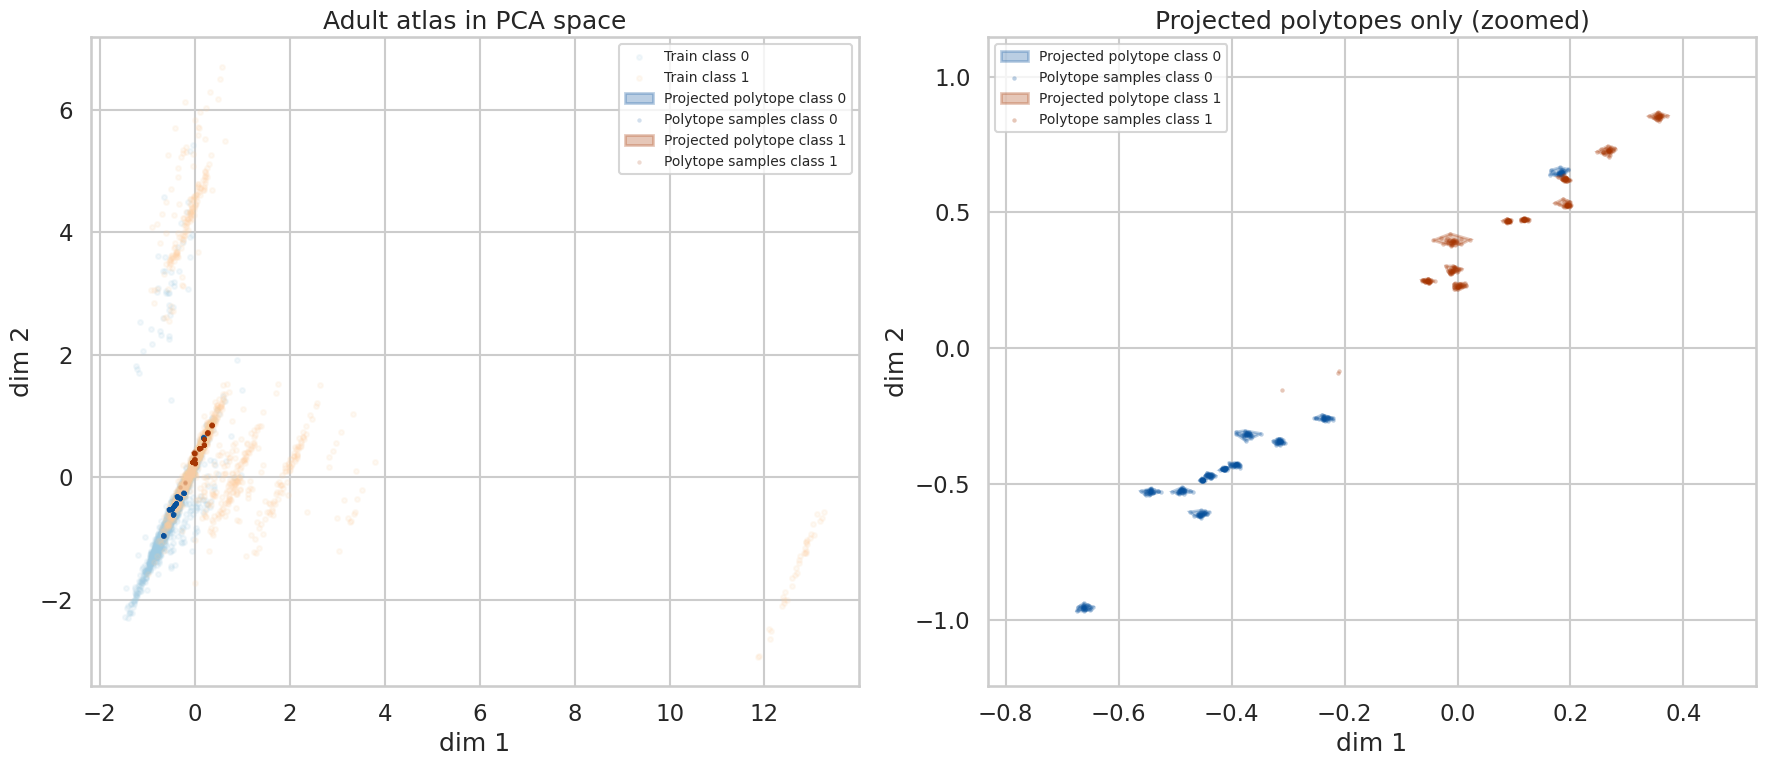

In [6]:
combined_df = _make_embedding_frames(bundle, selected_idx, polytope_cloud_df)
feature_cols = list(range(bundle['x_train'].shape[1]))

pca_fit_idx = _sample_indices_per_class(bundle['y_train'], bundle['class_labels'], VIS_POINTS_PER_CLASS, seed_offset=111)
pca = _fit_pca(bundle['x_train'][pca_fit_idx], n_components=2)
pca_coords = pca.transform(combined_df[feature_cols].to_numpy(dtype=np.float64))

pca_df = combined_df[['kind', 'class_label', 'selected_train_idx', 'anchor_idx']].copy()
pca_df['dim_1'] = pca_coords[:, 0]
pca_df['dim_2'] = pca_coords[:, 1]

explained = pd.DataFrame([
    {
        'pc1_explained_variance_ratio': float(pca.explained_variance_ratio_[0]),
        'pc2_explained_variance_ratio': float(pca.explained_variance_ratio_[1]),
        'pc12_total_explained_variance_ratio': float(np.sum(pca.explained_variance_ratio_[:2])),
    }
])
display(explained)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
_plot_pca_polytopes(pca_df, 'Adult atlas in PCA space', ax=axes[0], show_support=True, zoom_to_polytopes=False)
_plot_pca_polytopes(pca_df, 'Projected polytopes only (zoomed)', ax=axes[1], show_support=False, zoom_to_polytopes=True)
plt.tight_layout()
plt.show()


## Input-space PCA by label

This section shows the Adult data directly in input space after a 2D PCA projection. The plots are shown twice by label source: ground-truth labels and predicted labels. For each labeling, one panel shows the full sampled support and one panel shows a tighter PCA zoom.


,pc1_explained_variance_ratio,pc2_explained_variance_ratio,pc12_total_explained_variance_ratio,train_subset_accuracy
0,0.200148,0.135597,0.335746,0.780333


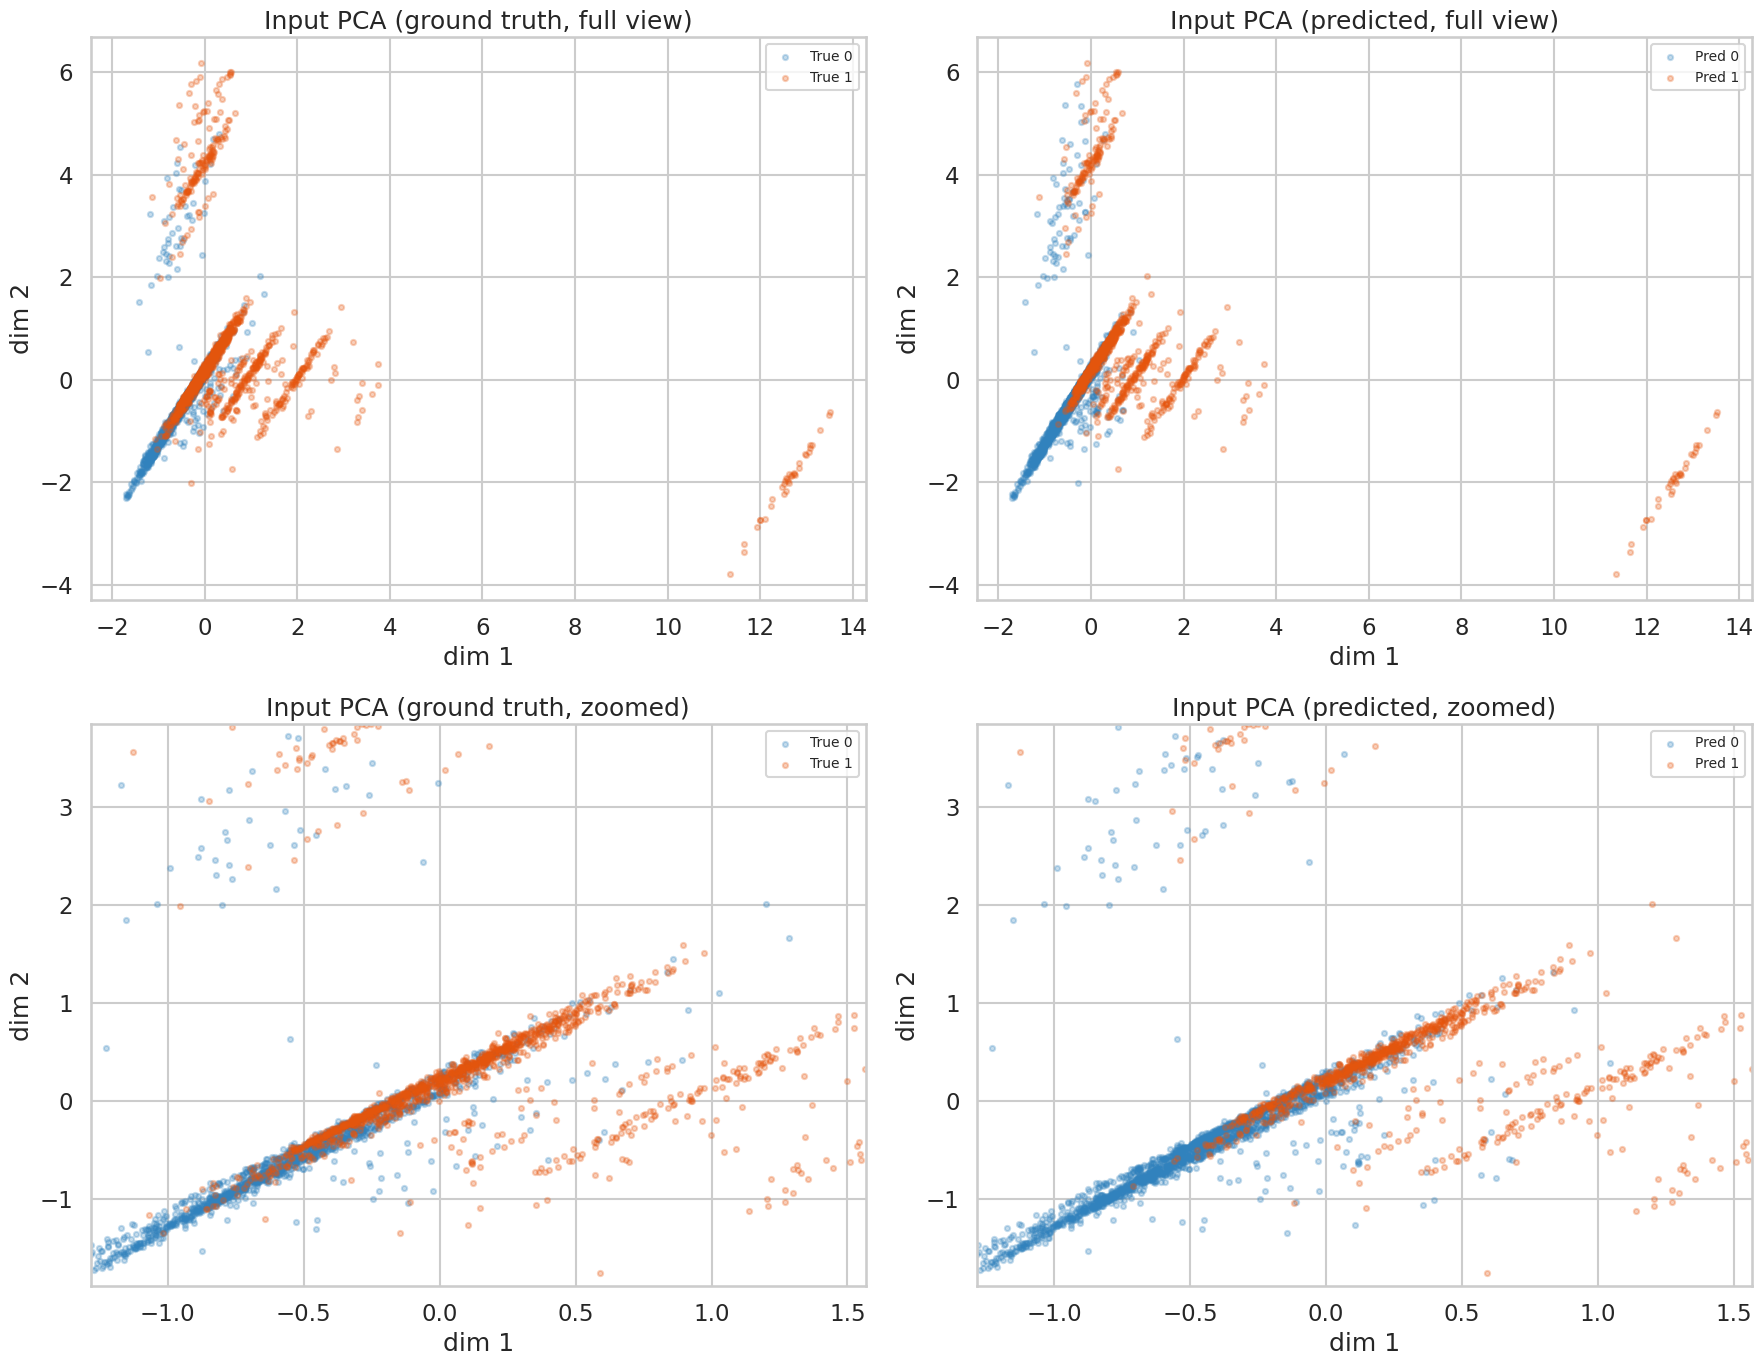

In [7]:
input_fit_idx = _sample_indices_per_class(bundle['y_train'], bundle['class_labels'], VIS_POINTS_PER_CLASS, seed_offset=444)
input_points = bundle['x_train'][input_fit_idx]
input_logits = _batched_logits(bundle['model'], input_points)
input_pred = input_logits.argmax(axis=1).astype(np.int64)

input_pca = PCA(n_components=2, random_state=SEED)
input_pca_coords = input_pca.fit_transform(input_points)
input_pca_df = pd.DataFrame({
    'class_label': bundle['y_train'][input_fit_idx],
    'predicted_label': input_pred,
    'dim_1': input_pca_coords[:, 0],
    'dim_2': input_pca_coords[:, 1],
})

input_summary = pd.DataFrame([
    {
        'pc1_explained_variance_ratio': float(input_pca.explained_variance_ratio_[0]),
        'pc2_explained_variance_ratio': float(input_pca.explained_variance_ratio_[1]),
        'pc12_total_explained_variance_ratio': float(np.sum(input_pca.explained_variance_ratio_[:2])),
        'train_subset_accuracy': float(np.mean(input_pca_df['class_label'] == input_pca_df['predicted_label'])),
    }
])
display(input_summary)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
_plot_embedding_points(
    input_pca_df,
    'Input PCA (ground truth, full view)',
    ax=axes[0, 0],
    label_col='class_label',
    legend_prefix='True',
)
_plot_embedding_points(
    input_pca_df,
    'Input PCA (predicted, full view)',
    ax=axes[0, 1],
    label_col='predicted_label',
    legend_prefix='Pred',
)
_plot_embedding_points(
    input_pca_df,
    'Input PCA (ground truth, zoomed)',
    ax=axes[1, 0],
    label_col='class_label',
    legend_prefix='True',
    zoom_quantiles=(0.05, 0.95),
)
_plot_embedding_points(
    input_pca_df,
    'Input PCA (predicted, zoomed)',
    ax=axes[1, 1],
    label_col='predicted_label',
    legend_prefix='Pred',
    zoom_quantiles=(0.05, 0.95),
)

plt.tight_layout()
plt.show()


## Penultimate-layer feature space

This section loads the Adult classifier representation right before the last linear layer and visualizes data points in that learned feature space. The plots are shown twice: once colored by ground-truth labels and once colored by predicted labels, so you can compare the learned representation against the model decision pattern.


,embedding_dim,pc1_explained_variance_ratio,pc2_explained_variance_ratio,pc12_total_explained_variance_ratio,train_subset_accuracy
0,8,0.735974,0.257702,0.993676,0.788


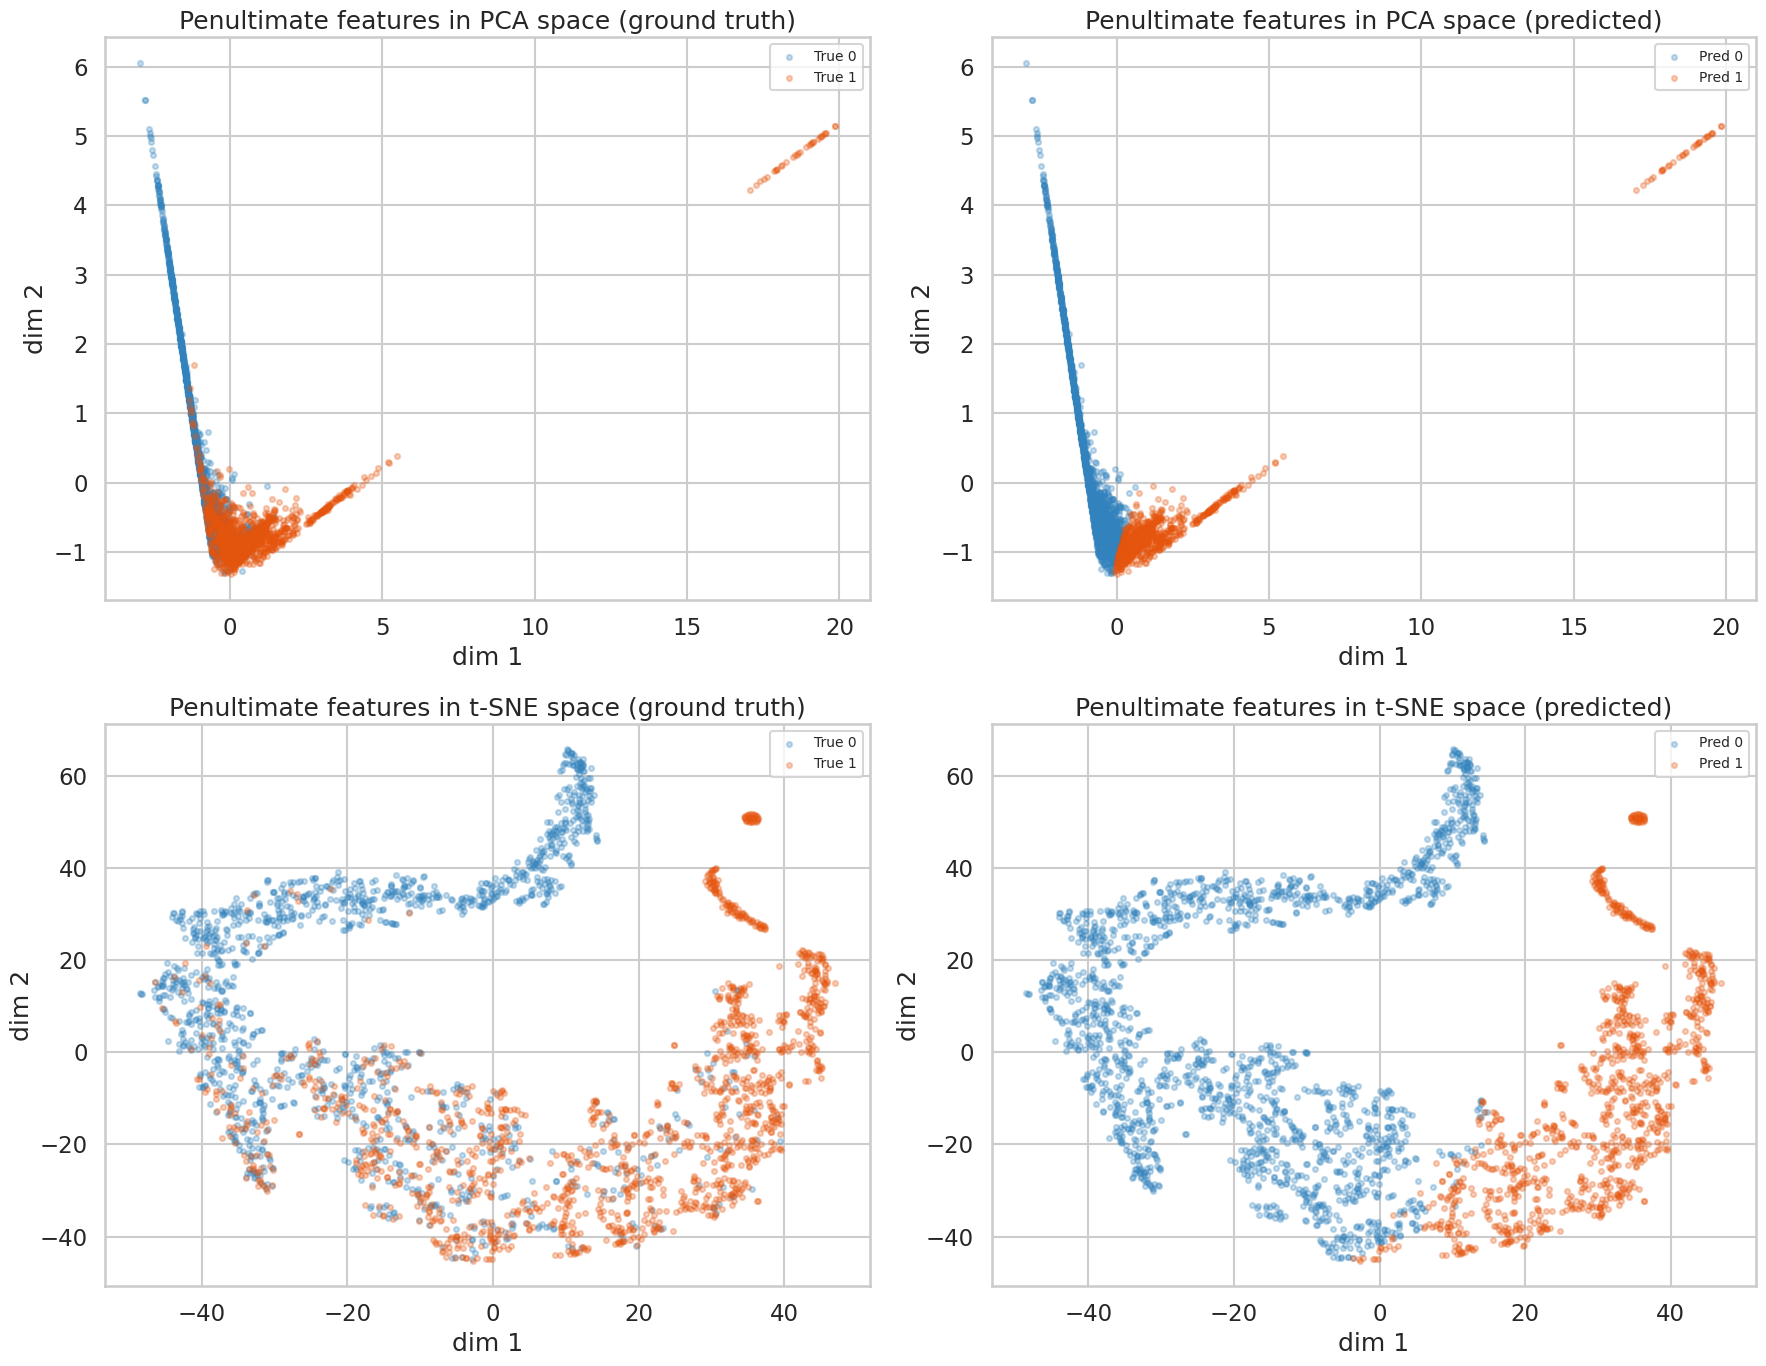

In [8]:
feature_fit_idx = _sample_indices_per_class(bundle['y_train'], bundle['class_labels'], VIS_POINTS_PER_CLASS, seed_offset=333)
feature_embeddings = _batched_penultimate_embeddings(bundle['model'], bundle['x_train'][feature_fit_idx])
feature_logits = _batched_logits(bundle['model'], bundle['x_train'][feature_fit_idx])
feature_pred = feature_logits.argmax(axis=1).astype(np.int64)

feature_df = pd.DataFrame({
    'class_label': bundle['y_train'][feature_fit_idx],
    'predicted_label': feature_pred,
})

feature_pca = PCA(n_components=2, random_state=SEED)
feature_pca_coords = feature_pca.fit_transform(feature_embeddings)
feature_pca_df = feature_df.copy()
feature_pca_df['dim_1'] = feature_pca_coords[:, 0]
feature_pca_df['dim_2'] = feature_pca_coords[:, 1]

feature_summary = pd.DataFrame([
    {
        'embedding_dim': int(feature_embeddings.shape[1]),
        'pc1_explained_variance_ratio': float(feature_pca.explained_variance_ratio_[0]),
        'pc2_explained_variance_ratio': float(feature_pca.explained_variance_ratio_[1]),
        'pc12_total_explained_variance_ratio': float(np.sum(feature_pca.explained_variance_ratio_[:2])),
        'train_subset_accuracy': float(np.mean(feature_df['class_label'] == feature_df['predicted_label'])),
    }
])
display(feature_summary)

feature_tsne_coords = _fit_tsne(feature_embeddings)
feature_tsne_df = feature_df.copy()
feature_tsne_df['dim_1'] = feature_tsne_coords[:, 0]
feature_tsne_df['dim_2'] = feature_tsne_coords[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
_plot_embedding_points(
    feature_pca_df,
    'Penultimate features in PCA space (ground truth)',
    ax=axes[0, 0],
    label_col='class_label',
    legend_prefix='True',
)
_plot_embedding_points(
    feature_pca_df,
    'Penultimate features in PCA space (predicted)',
    ax=axes[0, 1],
    label_col='predicted_label',
    legend_prefix='Pred',
)
_plot_embedding_points(
    feature_tsne_df,
    'Penultimate features in t-SNE space (ground truth)',
    ax=axes[1, 0],
    label_col='class_label',
    legend_prefix='True',
)
_plot_embedding_points(
    feature_tsne_df,
    'Penultimate features in t-SNE space (predicted)',
    ax=axes[1, 1],
    label_col='predicted_label',
    legend_prefix='Pred',
)

plt.tight_layout()
plt.show()


## Optional t-SNE view

`t-SNE` is included as a secondary view for local neighborhoods. It is less faithful than PCA for global geometry, so it should be read as an exploratory visualization rather than a geometric summary of the certified regions. For that reason, this view keeps only the polytope sample point clouds and does not draw polygon shapes.

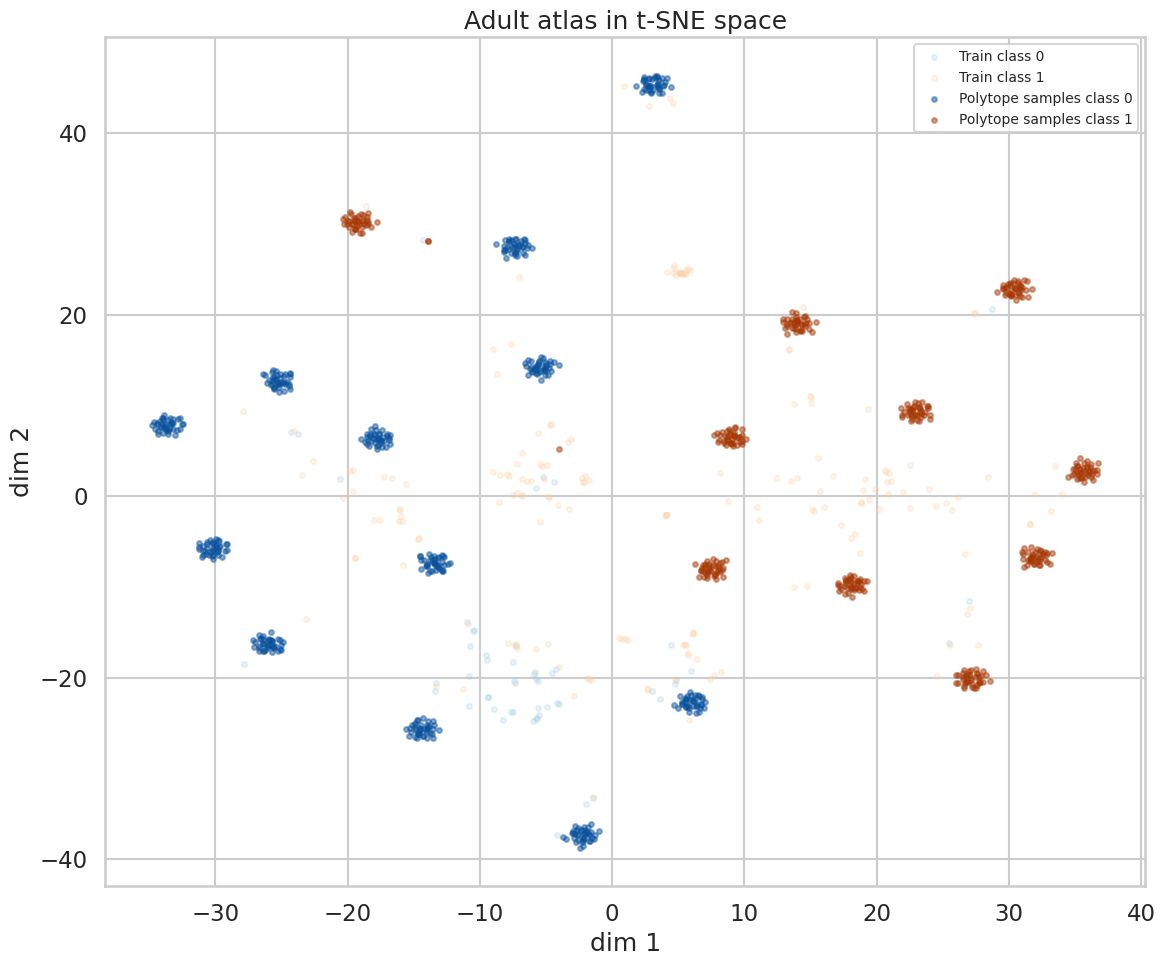

In [9]:
tsne_base_idx = _sample_indices_per_class(bundle['y_train'], bundle['class_labels'], TSNE_POINTS_PER_CLASS, seed_offset=222)
base_mask = (combined_df['kind'] != 'train_support') | combined_df['selected_train_idx'].isin(tsne_base_idx)
tsne_input = combined_df.loc[base_mask].reset_index(drop=True)
tsne_coords = _fit_tsne(tsne_input[feature_cols].to_numpy(dtype=np.float64))

tsne_df = tsne_input[['kind', 'class_label', 'selected_train_idx', 'anchor_idx']].copy()
tsne_df['dim_1'] = tsne_coords[:, 0]
tsne_df['dim_2'] = tsne_coords[:, 1]

fig, ax = plt.subplots(figsize=(12, 10))
_plot_tsne_embedding(tsne_df, 'Adult atlas in t-SNE space', ax=ax)
plt.tight_layout()
plt.show()

## Quick inspection of sampled anchors

This last cell shows which selected training points were used for the polytope clouds, together with their classes and training margins.

In [10]:
anchor_inspection = polytope_sampling_summary[['class_label', 'anchor_idx', 'selected_train_idx', 'ball_eps', 'n_accepted', 'acceptance_rate']].copy()
anchor_inspection['training_margin'] = bundle['margin_scores'][anchor_inspection['selected_train_idx'].to_numpy(dtype=np.int64)]
anchor_inspection = anchor_inspection.sort_values(['class_label', 'anchor_idx']).reset_index(drop=True)
display(anchor_inspection)

,class_label,anchor_idx,selected_train_idx,ball_eps,n_accepted,acceptance_rate,training_margin
0,0,5,7815,0.235247,40,0.019531,0.947547
1,0,16,20040,0.450000,40,0.019531,2.404275
2,0,22,27266,0.155777,40,0.019531,1.100937
3,0,49,24531,0.450000,40,0.019531,5.051769
4,0,59,6605,0.355065,40,0.019531,0.943282
5,0,83,3802,0.450000,40,0.019531,1.121216
6,0,96,27590,0.450000,40,0.019531,2.022099
7,0,107,24014,0.340375,40,0.019531,1.281775
8,0,129,10160,0.450000,40,0.019531,1.114969
9,0,151,695,0.524358,40,0.019531,0.257123
